In [1]:
import pandas as pd
import numpy as np
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

csv_file = os.path.join(path, "creditcard.csv")

df = pd.read_csv(csv_file)
df


Using Colab cache for faster access to the 'creditcardfraud' dataset.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


1. Problem Understanding

What is Fraud Detection?

Fraud detection is the process of identifying suspicious financial transactions that may indicate illegal activity.

Why is Fraud Detection Difficult?
Fraudulent transactions are extremely rare.
Fraud patterns continuously evolve.
Labelled fraud data is often unavailable or delayed.


Why Use Unsupervised Learning?
Unsupervised learning does not require labelled data. It identifies unusual patterns and anomalies that differ from normal transactions, making it suitable for real-world fraud detection scenarios.

2. Exploratory Data Analysis (EDA)


In [2]:
df.shape

(284807, 31)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [5]:
df.duplicated().sum()

np.int64(1081)

In [6]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [7]:
# total 492 frauds detected

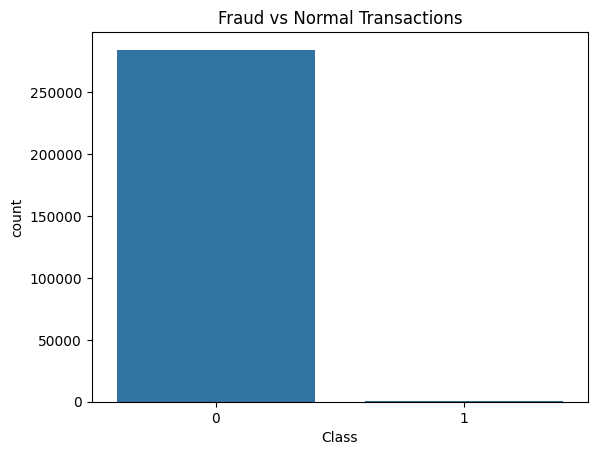

In [8]:
#visulization
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

Insights
Dataset contains 284,807 transactions.
Only 492 are fraud transactions.
Fraud percentage is approximately 0.17%.

3. Data Preprocessing

In [9]:
X = df.drop('Class', axis=1)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Why Scaling?
K-Means uses distance calculations.
Isolation Forest performs better with standardized features.
Amount and Time have different scales.

4. Clustering Approach (K-Means)

Why K-Means?

K-Means groups similar transactions together and helps identify clusters that may contain abnormal transactions.




In [11]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

In [12]:
pd.Series(clusters).value_counts()

,count
0,155337
1,129470


In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)

print(score)

Interpretation
Larger cluster → Normal transactions
Smaller cluster → Potential anomalies
Weakness

K-Means assumes spherical clusters and struggles with highly imbalanced datasets.

5. Anomaly Detection Approach (Isolation Forest)


Why Isolation Forest?

Isolation Forest is specifically designed to detect anomalies.

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.002,random_state=42)

pred = iso.fit_predict(X_scaled)

In [ ]:
pred = np.where(pred == -1, 1, 0)

In [ ]:
np.sum(pred)

Interpretation

Transactions isolated quickly by random trees are considered anomalies.

Strength

Works very well on high-dimensional and imbalanced datasets.

6. Comparison of Methods
Isolation Forest is expected to detect more meaningful anomalies because it focuses on isolation rather than cluster formation.

7. Bonus Evaluation

In [ ]:
y_true = df['Class']

In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, pred)

print(cm)

In [ ]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_true, pred))

In [ ]:
#Precision
from sklearn.metrics import precision_score

precision_score(y_true, pred)

In [ ]:
#Recall
from sklearn.metrics import recall_score

recall_score(y_true, pred)

Interpretation
Precision → How many detected frauds are actually fraud.
Recall → How many actual frauds were detected.
Higher recall is usually preferred in fraud detection.

8. Final Conclusion
Business Perspective

This project developed an unsupervised fraud detection system using K-Means Clustering and Isolation Forest. The dataset exhibited severe class imbalance, making fraud identification challenging.

K-Means was able to group transactions into clusters but struggled to separate rare fraud transactions effectively.

Isolation Forest demonstrated superior anomaly detection capability by isolating unusual transactions without relying on labels.

Recommendation

Isolation Forest should be preferred for real-world fraud detection systems because:

Better anomaly detection capability
Handles imbalanced data effectively
Scales well to large datasets
Does not require labelled training data